# CardioScope-XAI — Preprocessing Pipeline
Runs the full preprocessing pipeline and saves the processed dataset to `data/processed/`.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_and_clean, split_features_target
from src.feature_engineering import build_feature_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

## 1. Load and Clean

In [2]:
df = load_and_clean('../data/raw/heart_disease_uci.csv')
print(df.shape)
df.head()

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137
(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


## 2. Feature Engineering + Encoding + Scaling

In [3]:
X, scaler = build_feature_matrix(df, fit_scaler=True)
y = df['target'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'\nFeature columns ({len(X.columns)}):')
print(X.columns.tolist())

[feature_engineering] Scaler fitted and saved to models\scaler.pkl
[feature_engineering] Final feature matrix: 25 features, 297 samples.
Feature matrix shape: (297, 25)

Feature columns (25):
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'map_value', 'pulse_pressure', 'chol_hr_ratio', 'hr_reserve', 'hr_reserve_pct', 'st_risk_index', 'age_bp_index', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'thal_6', 'thal_7']


## 3. Engineered Feature Distributions

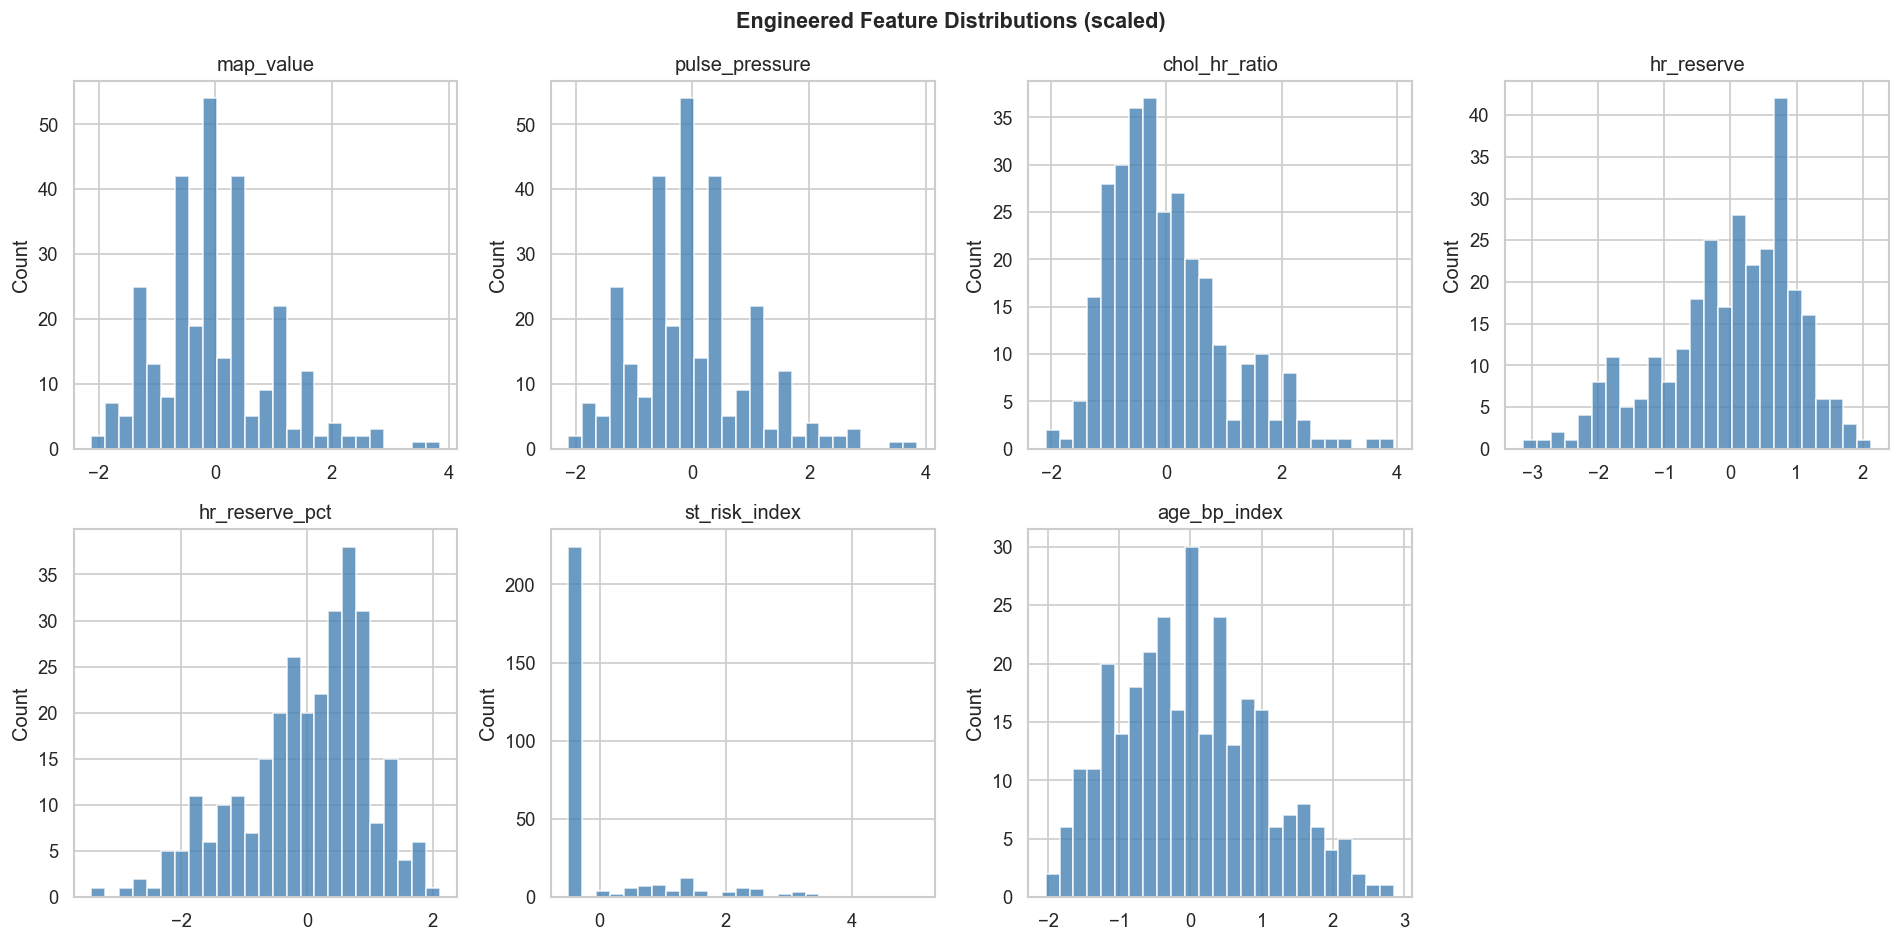

In [4]:
engineered = ['map_value', 'pulse_pressure', 'chol_hr_ratio',
              'hr_reserve', 'hr_reserve_pct', 'st_risk_index', 'age_bp_index']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(engineered):
    axes[i].hist(X[feat], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat)
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Engineered Feature Distributions (scaled)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Train class balance — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')
print(f'Test  class balance — 0: {(y_test==0).sum()}   1: {(y_test==1).sum()}')

Train: 237 samples  |  Test: 60 samples
Train class balance — 0: 128  1: 109
Test  class balance — 0: 32   1: 28


## 5. Save Processed Data

In [6]:
X_train_out = X_train.copy()
X_train_out['target'] = y_train.values

X_test_out = X_test.copy()
X_test_out['target'] = y_test.values

X_train_out.to_csv('../data/processed/train.csv', index=False)
X_test_out.to_csv('../data/processed/test.csv', index=False)

print('Saved: data/processed/train.csv')
print('Saved: data/processed/test.csv')

Saved: data/processed/train.csv
Saved: data/processed/test.csv


## 6. Feature Correlation with Target (After Engineering)

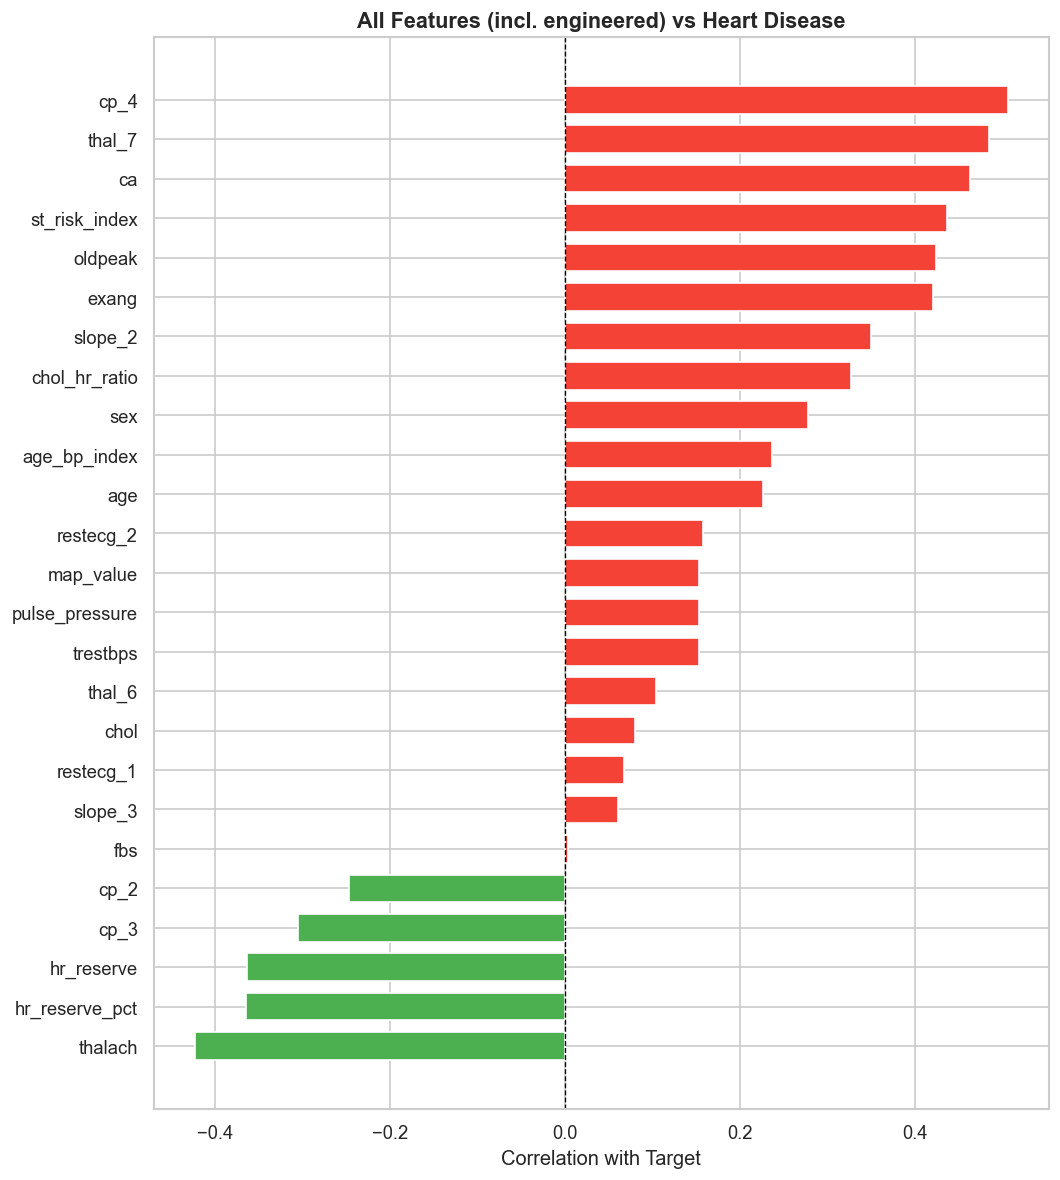

In [7]:
X_with_target = X.copy()
X_with_target['target'] = y.values

corr_with_target = X_with_target.corr()['target'].drop('target').sort_values()

colors = ['#F44336' if v > 0 else '#4CAF50' for v in corr_with_target.values]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Correlation with Target')
ax.set_title('All Features (incl. engineered) vs Heart Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Step | Output |
|---|---|
| Raw data | 303 rows × 14 cols |
| After cleaning | ~297 rows × 14 cols |
| After engineering + encoding | ~297 rows × 20+ cols |
| Train set | ~238 rows |
| Test set | ~59 rows |
| Saved scaler | `models/scaler.pkl` |
| Saved datasets | `data/processed/train.csv`, `data/processed/test.csv` |